# 04 Agrupamiento climatico de municipios del Magdalena

Fuente climatica: ERA5 diario por municipio, descargado sobre la coordenada de la cabecera
municipal (DIVIPOLA), no sobre el centroide del poligono. Cartografia: geojson municipal DANE.

# 1 Configuracion

In [1]:
import time
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

import openmeteo_requests
import requests_cache
from retry_requests import retry

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from sklearn.decomposition import PCA

import numpy as np

ROOT = Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
DATA = ROOT / "data"

RANDOM_STATE = 42
START_DATE = "2007-01-01"
END_DATE = "2024-12-31"
plt.rcParams["figure.dpi"] = 110

def norm(s):
    return unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().upper().strip()

# cliente Open-Meteo, mismo patron del notebook 02
om_session = retry(
    requests_cache.CachedSession(".cache_openmeteo", expire_after=-1),
    retries=5,
    backoff_factor=0.3,
)
om_client = openmeteo_requests.Client(session=om_session)

## Coordenada de referencia por municipio

La coordenada de consulta de cada municipio es la cabecera municipal del DIVIPOLA del DANE, no el
centroide del poligono. En municipios que se extienden desde la costa o el llano hasta la Sierra
Nevada, como Santa Marta, Cienaga, Fundacion y Aracataca, el centroide cae en la montaña y devuelve
un clima frio que no corresponde a la zona poblada. La cabecera ubica el punto donde vive la gente y
donde ocurre la transmision.

El centroide del poligono se calcula solo como respaldo, para municipios sin cabecera registrada. En
el Magdalena los treinta municipios tienen cabecera, asi que el respaldo no llega a activarse.

In [2]:
# coordenada preferida: cabecera municipal del DIVIPOLA (Tipo CM)
divipola = pd.read_csv(DATA / "raw" / "DIVIPOLA-Codigos_cabeceras-Centros_poblados.csv")
cabecera = divipola[
    (divipola["Código Departamento"].astype(str).str.zfill(2) == "47")
    & (divipola["Tipo*"] == "CM")
].rename(columns={
    "Codigo Municipio": "cod_municipio",
    "Nombre Municipio": "municipio",
    "Latitud": "lat",
    "longitud": "lon",
}).copy()

for col in ["lat", "lon"]:
    cabecera[col] = pd.to_numeric(cabecera[col].astype(str).str.replace(",", "."), errors="coerce")
cabecera["cod_municipio"] = cabecera["cod_municipio"].astype(int)
cabecera["municipio"] = cabecera["municipio"].map(norm)
cabecera["fuente_coord"] = "cabecera"

# respaldo: centroide del poligono, solo para municipios sin cabecera
gdf_mag = gpd.read_file(DATA / "raw" / "MGN_ADM_MPIO_GRAFICO.geojson")
gdf_mag = gdf_mag[gdf_mag["dpto_ccdgo"] == "47"].copy()
gdf_mag["cod_municipio"] = gdf_mag["mpio_cdpmp"].astype(int)
centroide = gdf_mag.to_crs(epsg=3116).geometry.centroid.to_crs(epsg=4326)
gdf_mag["lat"] = centroide.y
gdf_mag["lon"] = centroide.x
gdf_mag["municipio"] = gdf_mag["mpio_cnmbr"].map(norm)
gdf_mag["fuente_coord"] = "centroide"

faltan_cabecera = gdf_mag[~gdf_mag["cod_municipio"].isin(cabecera["cod_municipio"])]
cols_coord = ["cod_municipio", "municipio", "lat", "lon", "fuente_coord"]
coords = (
    pd.concat([cabecera[cols_coord], faltan_cabecera[cols_coord]], ignore_index=True)
    .sort_values("cod_municipio")
    .reset_index(drop=True)
)

print("coordenadas por fuente:", coords["fuente_coord"].value_counts().to_dict())
coords

coordenadas por fuente: {'cabecera': 30}


,cod_municipio,municipio,lat,lon,fuente_coord
0,47001,SANTA MARTA,11.204679,-74.199829,cabecera
1,47030,ALGARROBO,10.188059,-74.061132,cabecera
2,47053,ARACATACA,10.589791,-74.186702,cabecera
3,47058,ARIGUANI,9.847047,-74.236515,cabecera
4,47161,CERRO DE SAN ANTONIO,10.325531,-74.868474,cabecera
5,47170,CHIVOLO,10.026631,-74.622242,cabecera
6,47189,CIENAGA,11.006654,-74.241286,cabecera
7,47205,CONCORDIA,10.257314,-74.833030,cabecera
8,47245,EL BANCO,9.008503,-73.974370,cabecera
9,47258,EL PINON,10.402781,-74.823094,cabecera


## Descarga climatica sobre la cabecera

Se descarga ERA5 diario por municipio desde Open-Meteo, el mismo producto y la misma funcion del
notebook 02, cambiando unicamente la coordenada por la de cabecera. De aqui salen las cinco variables
del perfil: temperatura media, maxima y minima, precipitacion y humedad relativa.

In [3]:
def get_era5_diario(lat, lon, start=START_DATE, end=END_DATE):
    res = om_client.weather_api(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": lat,
            "longitude": lon,
            "start_date": start,
            "end_date": end,
            "daily": [
                "temperature_2m_mean",
                "temperature_2m_max",
                "temperature_2m_min",
                "precipitation_sum",
                "relative_humidity_2m_mean",
            ],
            "models": "era5",
            "timezone": "America/Bogota",
        },
    )[0]
    daily = res.Daily()
    fechas = pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left",
    ).tz_localize(None).normalize()
    df = pd.DataFrame({
        "fecha": fechas,
        "t2m_media": daily.Variables(0).ValuesAsNumpy(),
        "t2m_max": daily.Variables(1).ValuesAsNumpy(),
        "t2m_min": daily.Variables(2).ValuesAsNumpy(),
        "precipitacion": daily.Variables(3).ValuesAsNumpy(),
        "humedad": daily.Variables(4).ValuesAsNumpy(),
    })
    df.replace(-999.0, np.nan, inplace=True)
    return df


path_era = DATA / "external" / "clima_era5_magdalena_cabecera_diario.parquet"

if path_era.exists():
    era = pd.read_parquet(path_era)
    era["fecha"] = era["fecha"].dt.normalize()
    print("cargado desde cache:", era.shape)
else:
    partes = []
    for fila in coords.itertuples():
        df = get_era5_diario(fila.lat, fila.lon)
        df["municipio"] = fila.municipio
        df["cod_municipio"] = fila.cod_municipio
        partes.append(df)
        print("OK", fila.municipio)
        time.sleep(18)
    era = pd.concat(partes, ignore_index=True)
    era.to_parquet(path_era, index=False)
    print("guardado:", path_era)

sub = pd.read_csv(DATA / "raw" / "subregiones.csv")
sub["key"] = sub["nombre_municipio"].map(norm)
era["key"] = era["municipio"].map(norm).replace({"CERRO DE SAN ANTONIO": "CERRO SAN ANTONIO"})

print(era["fecha"].min().date(), "->", era["fecha"].max().date(), "|", era["key"].nunique(), "municipios")
sub["subregion"].value_counts()

cargado desde cache: (197250, 8)
2007-01-01 -> 2024-12-31 | 30 municipios


subregion
Rio            9
Sur            7
Norte          7
Centro         6
Santa Marta    1
Name: count, dtype: int64

# 2 Perfil climatico por municipio

Cada municipio se resume por su promedio de largo plazo (2007-2024) en cuatro descriptores:
temperatura media, amplitud termica diaria (max - min), precipitacion y humedad.

In [4]:
era["amplitud"] = era["t2m_max"] - era["t2m_min"]

perfil = (
    era.groupby("key")
    .agg(
        t_media=("t2m_media", "mean"),
        amplitud=("amplitud", "mean"),
        precip=("precipitacion", "mean"),
        humedad=("humedad", "mean"),
    )
    .reset_index()
    .merge(sub, on="key")
)
# precipitacion sesgada a la derecha -> log (como en el articulo)
perfil["log_precip"] = np.log1p(perfil["precip"])
print("sesgo precip:", round(perfil["precip"].skew(), 2))

perfil[["nombre_municipio", "subregion", "t_media", "amplitud", "precip", "humedad"]].round(2)

sesgo precip: 0.3


,nombre_municipio,subregion,t_media,amplitud,precip,humedad
0,Algarrobo,Norte,28.150000,9.59,4.46,76.239998
1,Aracataca,Norte,28.299999,10.12,2.89,74.820000
2,Ariguani,Centro,28.400000,9.92,3.21,73.349998
3,Cerro San Antonio,Rio,28.980000,8.53,2.89,76.720001
4,Chivolo,Centro,27.969999,9.05,4.47,78.940002
5,Cienaga,Norte,27.920000,2.79,5.84,80.449997
6,Concordia,Rio,28.959999,8.53,2.89,76.720001
7,El Banco,Sur,28.600000,6.76,6.20,82.629997
8,El Pinon,Rio,28.719999,8.26,5.15,79.629997
9,El Reten,Norte,28.400000,10.12,2.89,74.830002


# 3 Bloque sociodemografico

Variables censales 2018 (DANE, via Terridata) unidas a perfil por codigo DIVIPOLA, agrupadas por el dominio que representan: agua (cobertura de acueducto), saneamiento en aguas residuales (alcantarillado), calidad de vivienda (deficit cualitativo).

In [5]:
TERRIDATA = DATA / "external" / "lookup" / "TerriData47000t.xlsx"

# nombre exacto del indicador en Terridata -> nombre corto de columna
MAPA_SOCIO = {
    "Cobertura de acueducto (Censo)":               "cob_acueducto",
    "Cobertura de alcantarillado (Censo)":          "cob_alcantarillado",
    "Déficit cualitativo de vivienda (Censo)":      "deficit_cualitativo",
}

td = pd.read_excel(TERRIDATA)

td_f = td[
    td["Indicador"].isin(MAPA_SOCIO)
    & (td["Año"] == 2018)
    & (td["Código Entidad"] != 47000)
].copy()

td_f["valor"] = pd.to_numeric(
    td_f["Dato Numérico"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce",
)

socio = (
    td_f.pivot_table(index="Código Entidad", columns="Indicador",
                     values="valor", aggfunc="first")
        .rename(columns=MAPA_SOCIO)
        .reset_index()
        .rename(columns={"Código Entidad": "cod_municipio"})
)
socio["cod_municipio"] = socio["cod_municipio"].astype(int)
socio = socio[["cod_municipio", "cob_acueducto", "cob_alcantarillado", "deficit_cualitativo"]]

key2cod = era.groupby("key")["cod_municipio"].first()
perfil["cod_municipio"] = perfil["key"].map(key2cod).astype(int)

# union final: cada indicador se renombra al dominio tematico que representa
socio = socio.rename(columns={
    "cob_acueducto":        "agua_potable",
    "cob_alcantarillado":   "aguas_residuales",
    "deficit_cualitativo":  "deficit_vivienda",
})
VARS_SOCIO = ["agua_potable", "aguas_residuales", "deficit_vivienda"]

perfil = perfil.merge(socio, on="cod_municipio", how="left")

assert len(perfil) == 30, f"se esperaban 30 municipios, hay {len(perfil)}"
faltantes = perfil[VARS_SOCIO].isna().sum().sum()
assert faltantes == 0, f"hay {faltantes} valores sociodemograficos sin cruzar"

print("OK: bloque sociodemografico unido |", perfil.shape, "| sin faltantes")
perfil

OK: bloque sociodemografico unido | (30, 12) | sin faltantes


,key,t_media,amplitud,precip,humedad,cod_municipio,nombre_municipio,subregion,log_precip,agua_potable,aguas_residuales,deficit_vivienda
0,ALGARROBO,28.152809,9.592729,4.456304,76.235786,47030,Algarrobo,Norte,1.696772,87.16,1.04,81.69
1,ARACATACA,28.304245,10.117880,2.892472,74.820236,47053,Aracataca,Norte,1.359044,66.70,33.70,60.62
2,ARIGUANI,28.401545,9.921879,3.213430,73.345024,47058,Ariguani,Centro,1.438277,64.82,10.77,76.26
3,CERRO SAN ANTONIO,28.984035,8.525139,2.890799,76.719360,47161,Cerro San Antonio,Rio,1.358614,69.30,1.15,75.17
4,CHIVOLO,27.968266,9.050684,4.471270,78.938599,47170,Chivolo,Centro,1.699511,65.91,45.29,59.00
5,CIENAGA,27.918606,2.788851,5.839696,80.445435,47189,Cienaga,Norte,1.922743,82.03,62.67,46.21
6,CONCORDIA,28.964535,8.525142,2.890799,76.716705,47205,Concordia,Rio,1.358614,84.36,7.94,82.87
7,EL BANCO,28.604198,6.760396,6.201201,82.632950,47245,El Banco,Sur,1.974248,55.58,30.04,60.52
8,EL PINON,28.721966,8.263271,5.145536,79.626312,47258,El Pinon,Rio,1.815726,73.95,28.38,69.75
9,EL RETEN,28.395245,10.117880,2.892472,74.833221,47268,El Reten,Norte,1.359044,82.98,7.73,79.49


# 4 Estructura de las variables

Correlacion entre los descriptores climaticos y sociodemograficos. Sirve para ver si aportan informacion distinta o si se reducen a un solo gradiente.

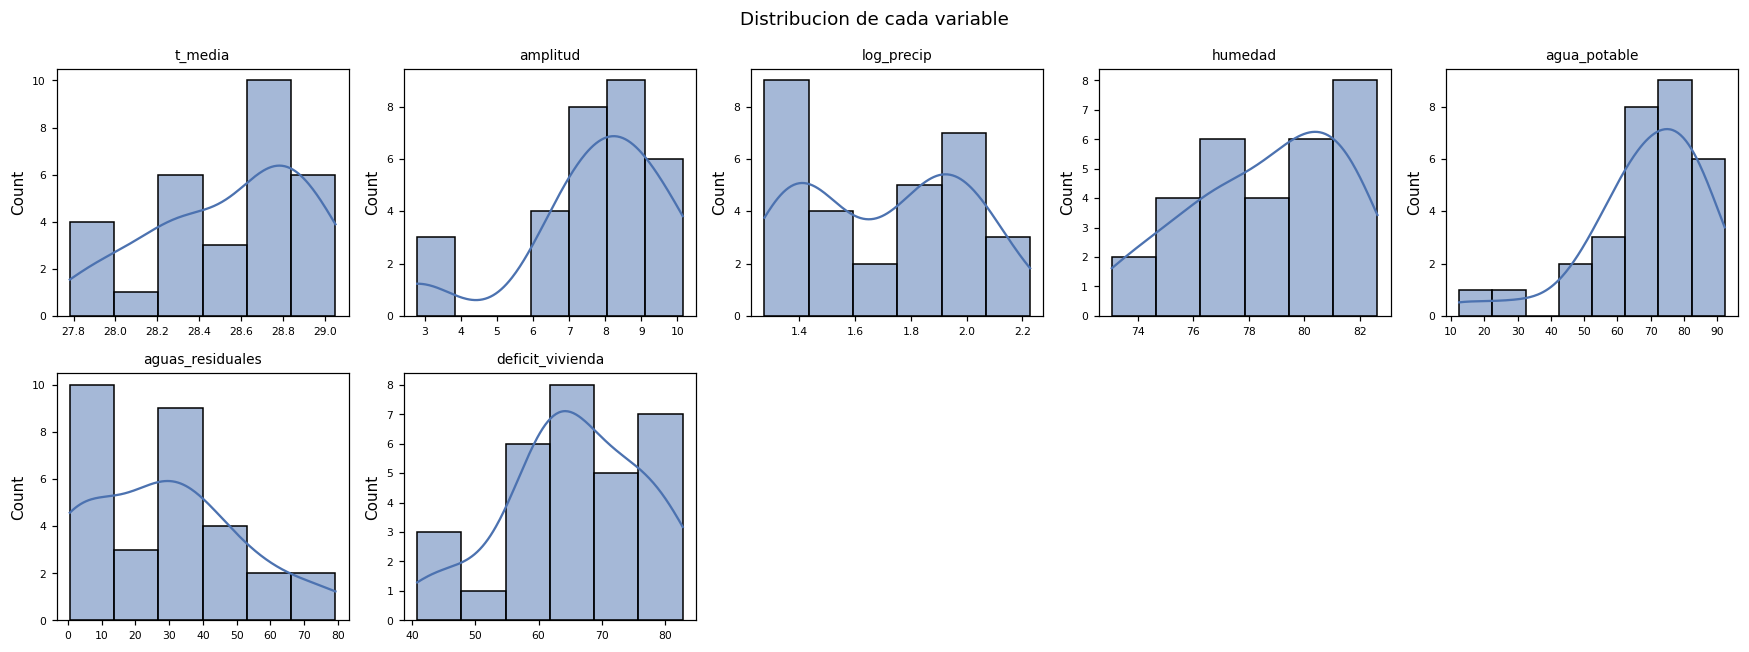

In [6]:
feats = ["t_media", "amplitud", "log_precip", "humedad",
         "agua_potable", "aguas_residuales", "deficit_vivienda"]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, f in zip(axes.flat, feats):
    sns.histplot(perfil[f], kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(feats):]:
    ax.set_axis_off()
fig.suptitle("Distribucion de cada variable")
plt.tight_layout(); plt.show()

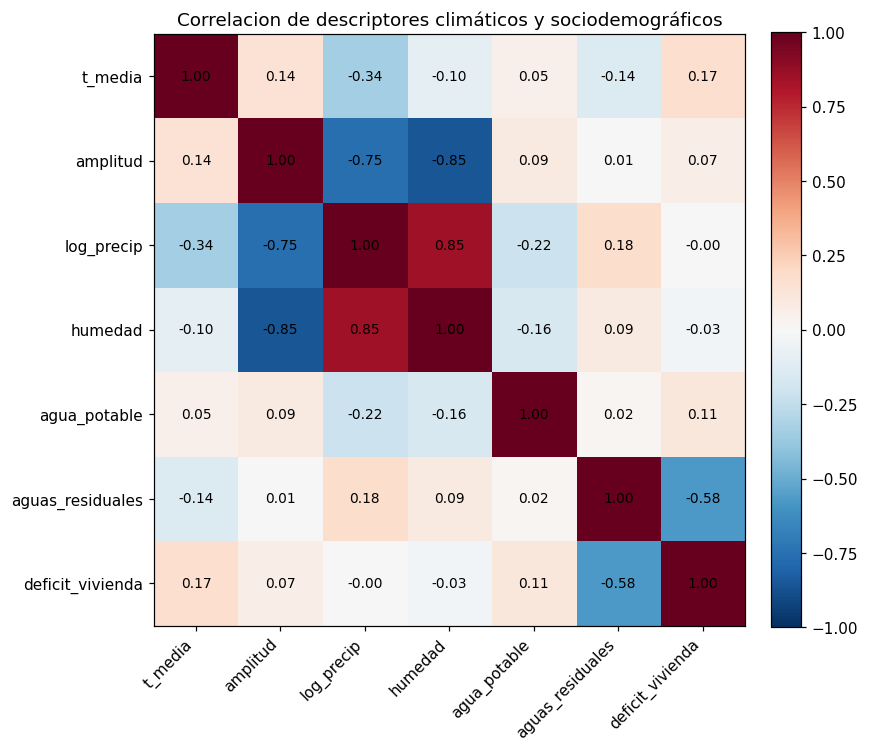

In [7]:
corr = perfil[feats].corr("spearman")

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha="right")
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats)
for i in range(len(feats)):
    for j in range(len(feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlacion de descriptores climáticos y sociodemográficos")
plt.tight_layout(); plt.show()

In [8]:

def leer_poblacion_dane(ruta):
    libro = pd.ExcelFile(ruta)
    for hoja in libro.sheet_names:
        vista = pd.read_excel(libro, sheet_name=hoja, header=None, nrows=30)
        m = vista[vista.iloc[:, 0].astype(str).str.strip() == "DP"]
        if not m.empty:
            df = pd.read_excel(libro, sheet_name=hoja, header=m.index[0])
            df.columns = [str(c).strip() for c in df.columns]
            col_pob = "TOTAL" if "TOTAL" in df.columns else "Población"
            return df.rename(columns={
                "DP": "cod_dpto", "MPIO": "cod_municipio", "AÑO": "ano",
                "ÁREA GEOGRÁFICA": "area", col_pob: "poblacion",
            })[["cod_dpto", "cod_municipio", "ano", "area", "poblacion"]]
    raise ValueError(f"no se encontro la fila de encabezado 'DP' en {ruta.name}")

pob = pd.concat([
    leer_poblacion_dane(DATA / "external" / "lookup" / "DCD-area-proypoblacion-Mun-2005-2017_VP.xlsx"),
    leer_poblacion_dane(DATA / "external" / "lookup" / "PPED-AreaMun-2018-2042_VP.xlsx"),
], ignore_index=True)

pob = pob.dropna(subset=["cod_municipio", "ano", "poblacion"])
pob["cod_municipio"] = pob["cod_municipio"].astype(int)
pob["ano"] = pob["ano"].astype(int)
pob = pob[
    (pob["cod_dpto"].astype(str).str.strip() == "47")
    & (pob["area"].astype(str).str.strip() == "Total")
    & pob["ano"].between(2007, 2024)
][["cod_municipio", "ano", "poblacion"]]

# casos de dengue (210) y dengue grave (220) en Magdalena, municipio de
# ocurrencia valido (cod_mun_completo ya viene validado contra DIVIPOLA)
casos = pd.read_parquet(
    DATA / "processed" / "df_clean.parquet",
    columns=["cod_eve", "ano", "cod_dpto_o", "cod_mun_completo", "mun_valido"],
)
casos = casos[
    casos["cod_eve"].isin([210, 220])
    & (casos["cod_dpto_o"] == 47)
    & casos["mun_valido"]
    & casos["ano"].between(2007, 2024)
]
casos_anio = (
    casos.groupby(["cod_mun_completo", "ano"]).size()
    .reset_index(name="casos")
    .rename(columns={"cod_mun_completo": "cod_municipio"})
)


incidencia_anual = casos_anio.merge(pob, on=["cod_municipio", "ano"], how="right")
incidencia_anual["casos"] = incidencia_anual["casos"].fillna(0)
incidencia_anual["incidencia"] = incidencia_anual["casos"] / incidencia_anual["poblacion"] * 100_000

# igual que las variables climaticas: cada municipio se resume por su
# promedio 2007-2024 (aqui, de la incidencia anual, no de casos acumulados)
incidencia_media = incidencia_anual.groupby("cod_municipio")["incidencia"].mean().reset_index()

perfil = perfil.merge(incidencia_media, on="cod_municipio", how="left")

faltantes = perfil["incidencia"].isna().sum()
assert faltantes == 0, f"hay {faltantes} municipios sin incidencia"
print("OK: incidencia de dengue unida |", perfil.shape)
perfil[["nombre_municipio", "incidencia"]].round(1)

OK: incidencia de dengue unida | (30, 13)


,nombre_municipio,incidencia
0,Algarrobo,51.7
1,Aracataca,100.4
2,Ariguani,225.3
3,Cerro San Antonio,17.2
4,Chivolo,162.5
5,Cienaga,72.7
6,Concordia,15.5
7,El Banco,67.0
8,El Pinon,46.5
9,El Reten,122.3


# 5 Reducción de dimensionalidad (PCA)

Bloque climatico y bloque social combinados en pocos ejes ortogonales. La incidencia de dengue queda fuera del PCA (variable suplementaria): se proyecta despues sobre los ejes ya formados, sin influir en su construccion.

In [9]:
feats_activas = ["t_media", "amplitud", "log_precip", "humedad",
         "agua_potable", "aguas_residuales", "deficit_vivienda"]

Xz = StandardScaler().fit_transform(perfil[feats_activas])
pca = PCA(random_state=RANDOM_STATE).fit(Xz)
var = pca.explained_variance_ratio_
acum = var.cumsum()

print("Varianza explicada por componente:")
for i, (v, a) in enumerate(zip(var, acum), 1):
    print(f"  PC{i}: {v*100:5.1f}%   acumulada: {a*100:5.1f}%")


N_COMP = 3
loadings = pd.DataFrame(
    pca.components_[:N_COMP].T,
    index=feats_activas,
    columns=[f"PC{i}" for i in range(1, N_COMP + 1)],
)
print("\nLoadings (cargas de cada variable en cada componente):")
print(loadings.round(2).to_string())


scores = pca.transform(Xz)[:, :N_COMP]
for i in range(N_COMP):
    perfil[f"pc{i+1}"] = scores[:, i]


print("\nIncidencia de dengue (suplementaria) vs componentes [Spearman]:")
for i in range(1, N_COMP + 1):
    r = perfil["incidencia"].corr(perfil[f"pc{i}"], method="spearman")
    print(f"  incidencia - PC{i}: {r:+.2f}")

Varianza explicada por componente:
  PC1:  40.1%   acumulada:  40.1%
  PC2:  24.3%   acumulada:  64.4%
  PC3:  15.7%   acumulada:  80.1%
  PC4:   9.6%   acumulada:  89.7%
  PC5:   6.3%   acumulada:  96.0%
  PC6:   2.8%   acumulada:  98.8%
  PC7:   1.2%   acumulada: 100.0%

Loadings (cargas de cada variable en cada componente):
                   PC1   PC2   PC3
t_media           0.32 -0.17  0.54
amplitud          0.51  0.08 -0.00
log_precip       -0.50 -0.27  0.18
humedad          -0.48 -0.27  0.39
agua_potable      0.18  0.26  0.69
aguas_residuales -0.23  0.62  0.19
deficit_vivienda  0.25 -0.61  0.08

Incidencia de dengue (suplementaria) vs componentes [Spearman]:
  incidencia - PC1: +0.02
  incidencia - PC2: +0.47
  incidencia - PC3: -0.12


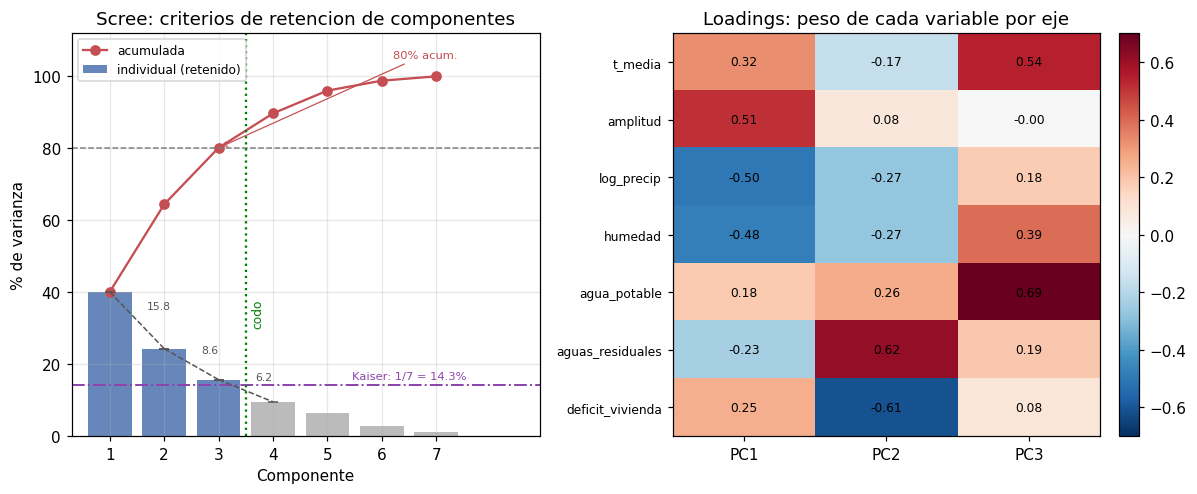

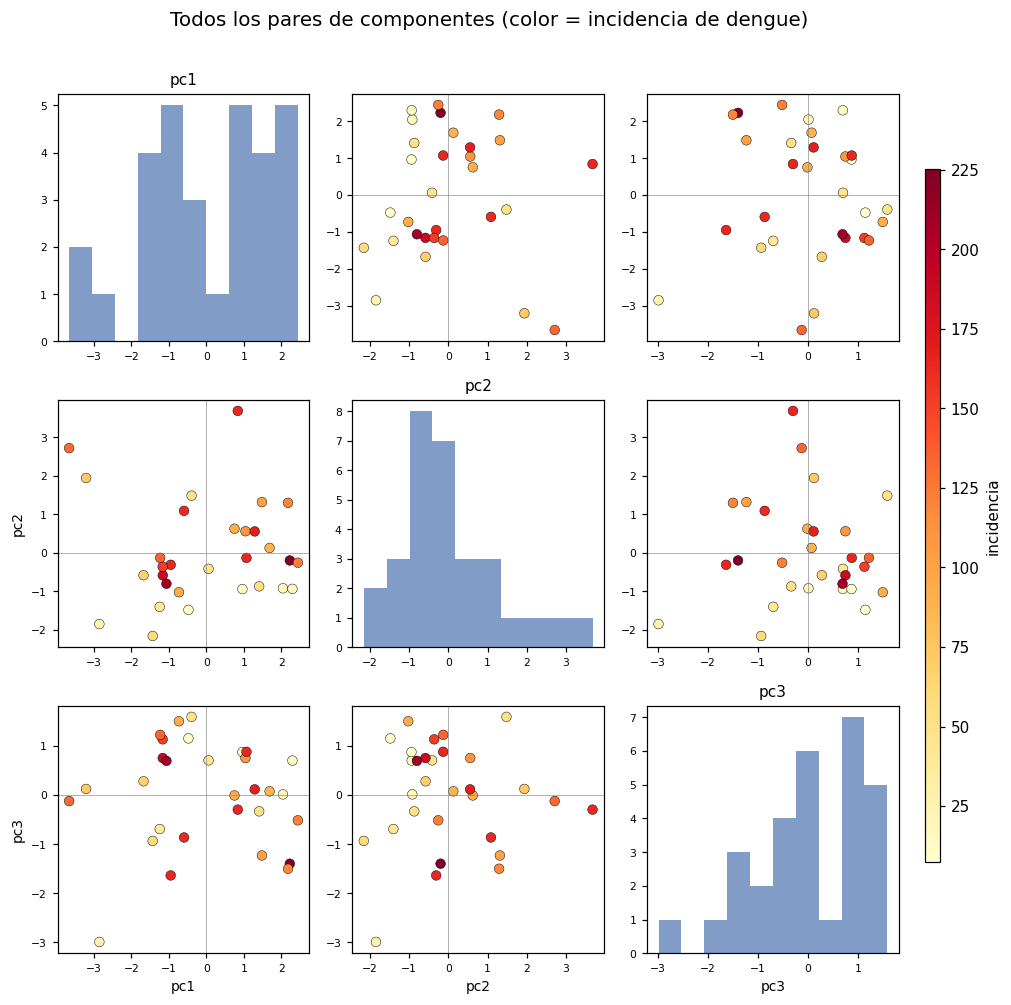

In [10]:


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# 1) SCREE: cuanta varianza aporta cada componente, con los 3 criterios de retencion
ax = axes[0]
comps = np.arange(1, len(var) + 1)
kaiser_umbral = 100 / len(feats_activas)  # lambda=1 en datos estandarizados == 1/p de la varianza
retenido = var * 100 > kaiser_umbral

ax.bar(comps[retenido], var[retenido] * 100, color="#4C72B0", alpha=0.85, label="individual (retenido)")
ax.bar(comps[~retenido], var[~retenido] * 100, color="#B0B0B0", alpha=0.85, label="_nolegend_")
ax.plot(comps, acum * 100, "o-", color="#C44E52", label="acumulada")

# Kaiser: valor propio = 1 en variables estandarizadas equivale a 1/p de la varianza total
KAISER_COLOR = "#8E44AD"
ax.axhline(kaiser_umbral, ls="-.", color=KAISER_COLOR, lw=1.3)
ax.text(6.5, kaiser_umbral + 1, f"Kaiser: 1/{len(feats_activas)} = {kaiser_umbral:.1f}%",
        color=KAISER_COLOR, fontsize=7.5, va="bottom", ha="center")

# Varianza acumulada: corte convencional en 80% + acumulado real en el corte de N_COMP
ax.axhline(80, ls="--", color="gray", lw=1)
ax.annotate(f"{acum[N_COMP - 1] * 100:.0f}% acum.",
            xy=(N_COMP, acum[N_COMP - 1] * 100), xytext=(N_COMP + 3.2, 106),
            fontsize=7.5, color="#C44E52", ha="left", va="center",
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=0.8))

# Codo: linea entre el tope de cada barra y la siguiente, con la caida marcada
caidas = -np.diff(var * 100)
for i in range(min(3, len(caidas))):
    x0, x1 = comps[i], comps[i + 1]
    y0, y1 = var[i] * 100, var[i + 1] * 100
    ax.plot([x0, x1], [y0, y1], ls="--", color="#555555", lw=1, marker="_", markersize=6)
    ax.text((x0 + x1) / 2 + 0.18, (y0 + y1) / 2 + 3, f"{abs(caidas[i]):.1f}",
            fontsize=7, color="#555555", ha="left")
ax.axvline(N_COMP + 0.5, ls=":", color="green", lw=1.5)
ax.text(N_COMP + 0.6, 30, "codo", color="green", fontsize=8, rotation=90, va="bottom", ha="left")

ax.set_xlabel("Componente"); ax.set_ylabel("% de varianza")
ax.set_xticks(comps)
ax.set_xlim(0.3, len(var) + 1.9)
ax.set_ylim(0, 112)
ax.set_title("Scree: criterios de retencion de componentes")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

# 2) LOADINGS: que variable pesa en cada eje 
ax = axes[1]
im = ax.imshow(loadings.values, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")
ax.set_xticks(range(loadings.shape[1])); ax.set_xticklabels(loadings.columns)
ax.set_yticks(range(len(feats_activas))); ax.set_yticklabels(feats_activas, fontsize=8)
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        ax.text(j, i, f"{loadings.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Loadings: peso de cada variable por eje")

plt.tight_layout(); plt.show()


pcs = [f"pc{i+1}" for i in range(N_COMP)]
n = len(pcs)

fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))
inc = perfil["incidencia"]

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            # diagonal: distribucion del componente
            ax.hist(perfil[pcs[i]], bins=10, color="#4C72B0", alpha=0.7)
            ax.set_title(pcs[i], fontsize=10)
        else:
            sc = ax.scatter(perfil[pcs[j]], perfil[pcs[i]], c=inc,
                            cmap="YlOrRd", s=40, edgecolor="k", linewidth=0.3)
            ax.axhline(0, color="gray", lw=0.4); ax.axvline(0, color="gray", lw=0.4)
        if i == n - 1:
            ax.set_xlabel(pcs[j], fontsize=9)
        if j == 0 and i != 0:
            ax.set_ylabel(pcs[i], fontsize=9)
        ax.tick_params(labelsize=7)

fig.suptitle("Todos los pares de componentes (color = incidencia de dengue)",
             fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0, 0.93, 1])
cbar_ax = fig.add_axes((0.94, 0.15, 0.015, 0.7))
fig.colorbar(sc, cax=cbar_ax, label="incidencia")
plt.show()

# 6 K-Means: ¿cuantos grupos?

Se estandarizan las variables y se barre K de 2 a 7. Se usa el codo (inercia) y el
coeficiente de silueta para decidir el numero de grupos.

In [11]:
pcs = [f"pc{i+1}" for i in range(N_COMP)] 
X = perfil[pcs].values

rows = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=25, random_state=RANDOM_STATE).fit(X)
    rows.append({
        "k": k,
        "inercia": km.inertia_,
        "silueta": silhouette_score(X, km.labels_),
        "davies_bouldin": davies_bouldin_score(X, km.labels_),
    })
barrido = pd.DataFrame(rows).set_index("k")
barrido.round(3)

,inercia,silueta,davies_bouldin
k,,,
2,102.298,0.353,1.079
3,74.147,0.381,1.043
4,54.794,0.379,0.893
5,39.294,0.387,0.829
6,32.439,0.365,0.855
7,27.808,0.344,0.771
8,21.435,0.347,0.692
9,17.268,0.362,0.609


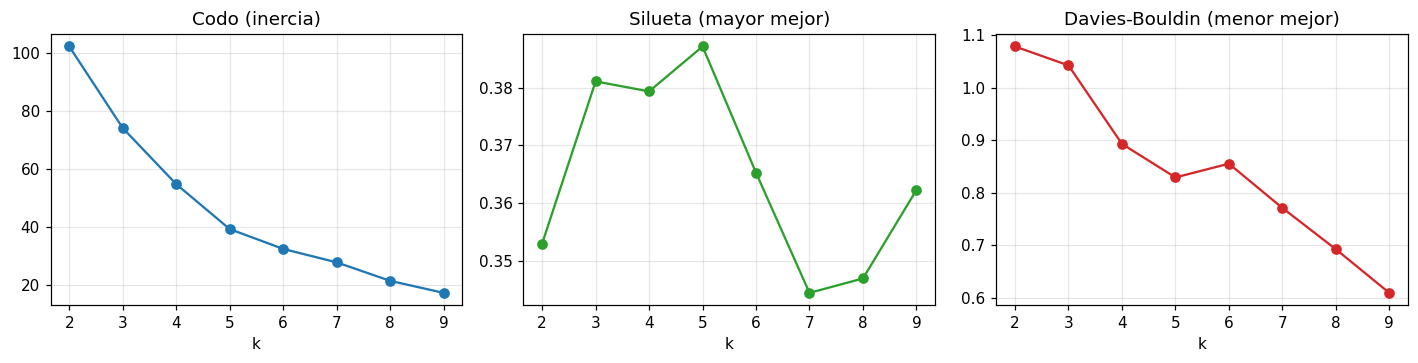

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(barrido.index, barrido["inercia"], "o-"); axes[0].set_title("Codo (inercia)")
axes[1].plot(barrido.index, barrido["silueta"], "o-", color="#2ca02c"); axes[1].set_title("Silueta (mayor mejor)")
axes[2].plot(barrido.index, barrido["davies_bouldin"], "o-", color="#d62728"); axes[2].set_title("Davies-Bouldin (menor mejor)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [13]:
K = 3
print("K seleccionado:", K)

K seleccionado: 3


# 7 Asignacion y caracterizacion de los grupos

In [14]:
km = KMeans(n_clusters=K, n_init=25, random_state=RANDOM_STATE).fit(X)
perfil["cluster"] = km.labels_

for c in sorted(perfil["cluster"].unique()):
    ms = perfil.loc[perfil["cluster"] == c, "nombre_municipio"].tolist()  #type: ignore
    print(f"Cluster {c} ({len(ms)}): {', '.join(ms)}") #type: ignore

Cluster 0 (5): Chivolo, Cienaga, Fundacion, Salamina, Santa Marta
Cluster 1 (13): Algarrobo, Aracataca, Ariguani, Cerro San Antonio, Concordia, El Reten, Pedraza, Pivijay, Plato, Sabanas de San Angel, Santa Barbara de Pinto, Tenerife, Zapayan
Cluster 2 (12): El Banco, El Pinon, Guamal, Nueva Granada, Pijino del Carmen, Puebloviejo, Remolino, San Sebastian de Buenavista, San Zenon, Santa Ana, Sitionuevo, Zona Bananera


## 8 Distribución Administrativa vs Distribución Cluster

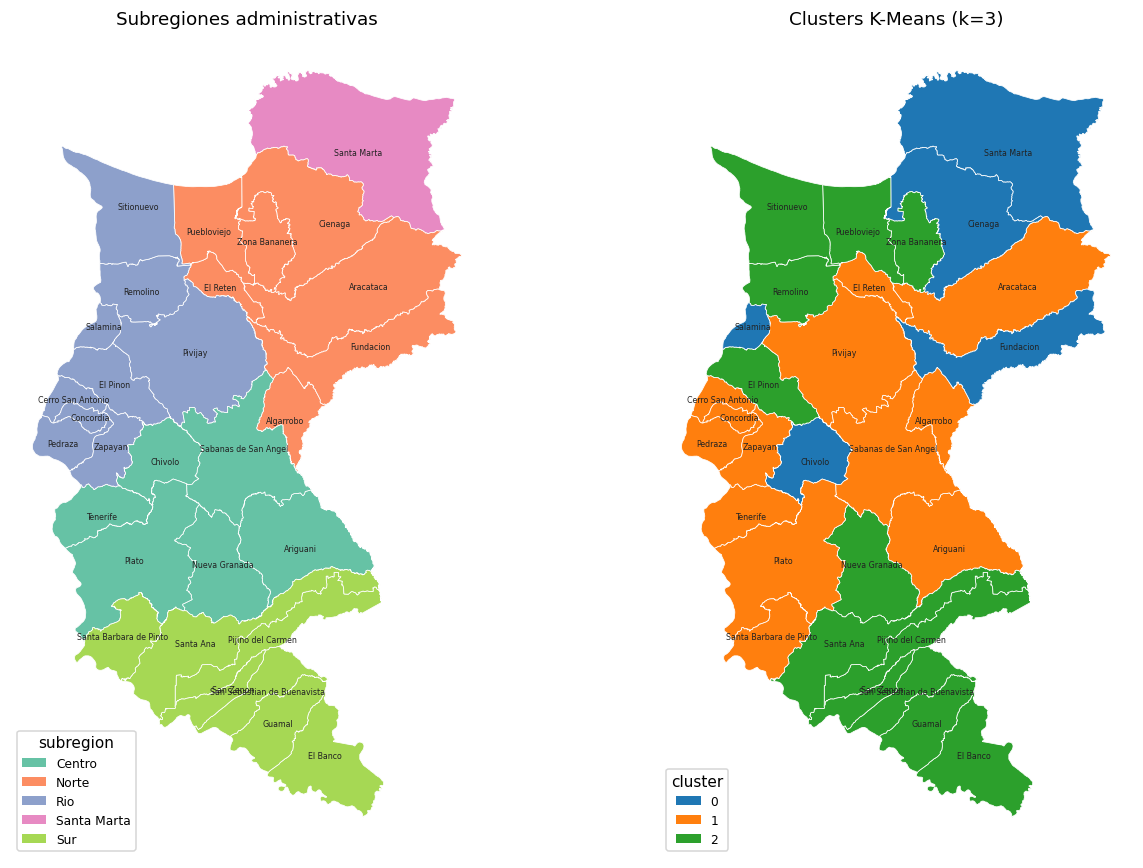

In [15]:
gdf = gpd.read_file(DATA / "raw" / "MGN_ADM_MPIO_GRAFICO.geojson")
mag = gdf[gdf["dpto_ccdgo"] == "47"].copy()
mag["cod_municipio"] = mag["mpio_cdpmp"].astype(int)
mag = mag.merge(perfil, on="cod_municipio")

# colores
subs = sorted(perfil["subregion"].unique())
sub_cmap = dict(zip(subs, plt.cm.Set2.colors))
clu = sorted(perfil["cluster"].unique())
clu_cmap = dict(zip(clu, plt.cm.tab10.colors))
mag["c_sub"] = mag["subregion"].map(sub_cmap)
mag["c_clu"] = mag["cluster"].map(clu_cmap)

fig, axes = plt.subplots(1, 2, figsize=(13, 8))

mag.plot(ax=axes[0], color=mag["c_sub"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Subregiones administrativas")
axes[0].legend(handles=[Patch(facecolor=sub_cmap[s], label=s) for s in subs],
               loc="lower left", fontsize=8, title="subregion")

mag.plot(ax=axes[1], color=mag["c_clu"], edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Clusters K-Means (k={K})")
axes[1].legend(handles=[Patch(facecolor=clu_cmap[c], label=f"{c}") for c in clu],
               loc="lower left", fontsize=8, title="cluster")

# etiquetas de municipio
for ax in axes:
    for _, r in mag.iterrows():
        pt = r.geometry.representative_point()
        ax.annotate(r["nombre_municipio"], (pt.x, pt.y), fontsize=5.2,
                    ha="center", va="center", color="#222")
    ax.set_axis_off()
plt.tight_layout(); plt.show()

# 9 Espacio Separación


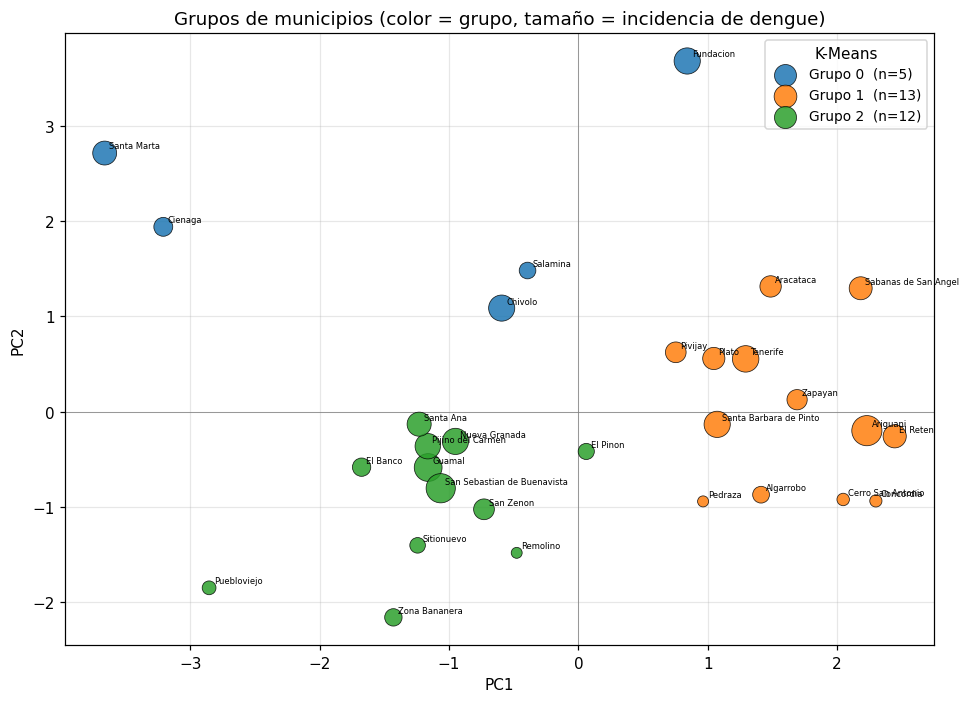

In [16]:
fig, ax = plt.subplots(figsize=(9, 6.5))

# tamaño del punto proporcional a la incidencia de dengue
sizes = 40 + (perfil["incidencia"] / perfil["incidencia"].max()) * 350

for c in sorted(perfil["cluster"].unique()):
    sub_c = perfil[perfil["cluster"] == c]
    ax.scatter(sub_c["pc1"], sub_c["pc2"],
               s=sizes[sub_c.index], color=clu_cmap[c],
               edgecolor="k", linewidth=0.5, alpha=0.85,
               label=f"Grupo {c}  (n={len(sub_c)})", zorder=3)

for _, r in perfil.iterrows():
    ax.annotate(r["nombre_municipio"], (r["pc1"], r["pc2"]), fontsize=5.5,
                xytext=(3, 3), textcoords="offset points")

ax.axhline(0, color="gray", lw=0.5); ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Grupos de municipios (color = grupo, tamaño = incidencia de dengue)")
ax.legend(loc="best", fontsize=9, title="K-Means")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [17]:
resumen_vars = [
    "t_media", "amplitud", "precip", "humedad",                # clima
    "agua_potable", "aguas_residuales",  # social
    "deficit_vivienda",
    "incidencia",
]

carac = perfil.groupby("cluster")[resumen_vars].mean()
carac["n_municipios"] = perfil["cluster"].value_counts().sort_index()

carac = carac.sort_values("incidencia")

print(carac.round(2).to_string())

           t_media  amplitud  precip    humedad  agua_potable  aguas_residuales  deficit_vivienda  incidencia  n_municipios
cluster                                                                                                                    
1        28.740000      8.99    3.21  76.360001         72.61             19.23             69.93       98.57            13
2        28.530001      6.88    6.32  81.029999         59.64             23.61             68.00       98.94            12
0        28.129999      6.60    4.84  78.849998         80.82             64.87             49.41      116.38             5


# 10 Exportacion para modelado por cluster

Se guarda el mapeo municipio -> cluster (K-Means, k=3) para que `06_dengue_modeling_cluster.ipynb` construya las series semanales de incidencia por cluster sin recalcular el clustering.

In [18]:
cols_export = ['cod_municipio', 'nombre_municipio', 'subregion', 'cluster']
out_path = DATA / 'processed' / 'df_municipal_clusters.parquet'
perfil[cols_export].to_parquet(out_path, index=False)
print(f'Guardado: {out_path}')
perfil[cols_export].sort_values('cluster')

Guardado: C:\Users\edavi\PROYECTOS\dengue-surveillance-magdalena\data\processed\df_municipal_clusters.parquet


,cod_municipio,nombre_municipio,subregion,cluster
5,47189,Cienaga,Norte,0
4,47170,Chivolo,Centro,0
10,47288,Fundacion,Norte,0
20,47675,Salamina,Rio,0
25,47001,Santa Marta,Santa Marta,0
2,47058,Ariguani,Centro,1
3,47161,Cerro San Antonio,Rio,1
0,47030,Algarrobo,Norte,1
15,47551,Pivijay,Rio,1
9,47268,El Reten,Norte,1
